In [1]:
import os
import re
import json
import pickle
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.utils import register_keras_serializable

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# =====================
# CONFIG
# =====================
SEED = 42

TOP_K = 15                 # Chọn top 10 category để train nhanh
MAX_SAMPLES_PER_CLASS = None # Đổi thành None nếu muốn dùng toàn bộ dữ liệu
MAX_WORDS = 30000
MAX_LEN = 30
EMBED_DIM = 128
LSTM_UNITS = 128
BATCH_SIZE = 128
EPOCHS = 20
LEARNING_RATE = 2e-3

# =====================
# Đường dẫn
# =====================
INPUT_PATH = "/kaggle/input/datasets/rmisra/news-category-dataset/News_Category_Dataset_v3.json"

OUTPUT_DIR = Path("/kaggle/working")
FEATURE_DIR = OUTPUT_DIR / "features"
MODEL_DIR = OUTPUT_DIR / "models"
RESULT_DIR = OUTPUT_DIR / "results"

FEATURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# =====================
# Reproducibility
# =====================
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Input path:", INPUT_PATH)
print("Output dir:", OUTPUT_DIR)

2026-05-08 14:24:33.494484: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778250273.689005      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778250273.742916      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778250274.171035      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778250274.171070      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778250274.171073      24 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
Input path: /kaggle/input/datasets/rmisra/news-category-dataset/News_Category_Dataset_v3.json
Output dir: /kaggle/working


In [2]:
df = pd.read_json(INPUT_PATH, lines=True)

print("Shape:", df.shape)
print(df.head())
print(df.columns)

Shape: (209527, 6)
                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Unt

In [3]:
df = df[["category", "headline", "short_description"]].copy()

df["headline"] = df["headline"].fillna("")
df["short_description"] = df["short_description"].fillna("")
df["text"] = df["headline"] + " " + df["short_description"]

print("Shape after removing empty text:", df.shape)
print(df[["category", "text"]].head())

Shape after removing empty text: (209527, 4)
    category                                               text
0  U.S. NEWS  Over 4 Million Americans Roll Up Sleeves For O...
1  U.S. NEWS  American Airlines Flyer Charged, Banned For Li...
2     COMEDY  23 Of The Funniest Tweets About Cats And Dogs ...
3  PARENTING  The Funniest Tweets From Parents This Week (Se...
4  U.S. NEWS  Woman Who Called Cops On Black Bird-Watcher Lo...


In [4]:
print("===== DATA OVERVIEW =====")
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicated rows:", df.duplicated().sum())
print("Duplicated text:", df["text"].duplicated().sum())

print("\nNumber of categories:", df["category"].nunique())

category_counts = df["category"].value_counts()
category_percent = df["category"].value_counts(normalize=True) * 100

label_dist = pd.DataFrame({
    "count": category_counts,
    "percent": category_percent
})

print("\nTop 20 categories:")
print(label_dist.head(20))

print("\nBottom 20 categories:")
print(label_dist.tail(20))

label_dist.to_csv(RESULT_DIR / "eda_category_distribution.csv")

===== DATA OVERVIEW =====
Shape: (209527, 4)

Missing values:
category             0
headline             0
short_description    0
text                 0
dtype: int64

Duplicated rows: 471
Duplicated text: 489

Number of categories: 42

Top 20 categories:
                count    percent
category                        
POLITICS        35602  16.991605
WELLNESS        17945   8.564529
ENTERTAINMENT   17362   8.286283
TRAVEL           9900   4.724928
STYLE & BEAUTY   9814   4.683883
PARENTING        8791   4.195641
HEALTHY LIVING   6694   3.194815
QUEER VOICES     6347   3.029204
FOOD & DRINK     6340   3.025863
BUSINESS         5992   2.859775
COMEDY           5400   2.577233
SPORTS           5077   2.423077
BLACK VOICES     4583   2.187308
HOME & LIVING    4320   2.061787
PARENTS          3955   1.887585
THE WORLDPOST    3664   1.748701
WEDDINGS         3653   1.743451
WOMEN            3572   1.704792
CRIME            3562   1.700020
IMPACT           3484   1.662793

Bottom 20 categor

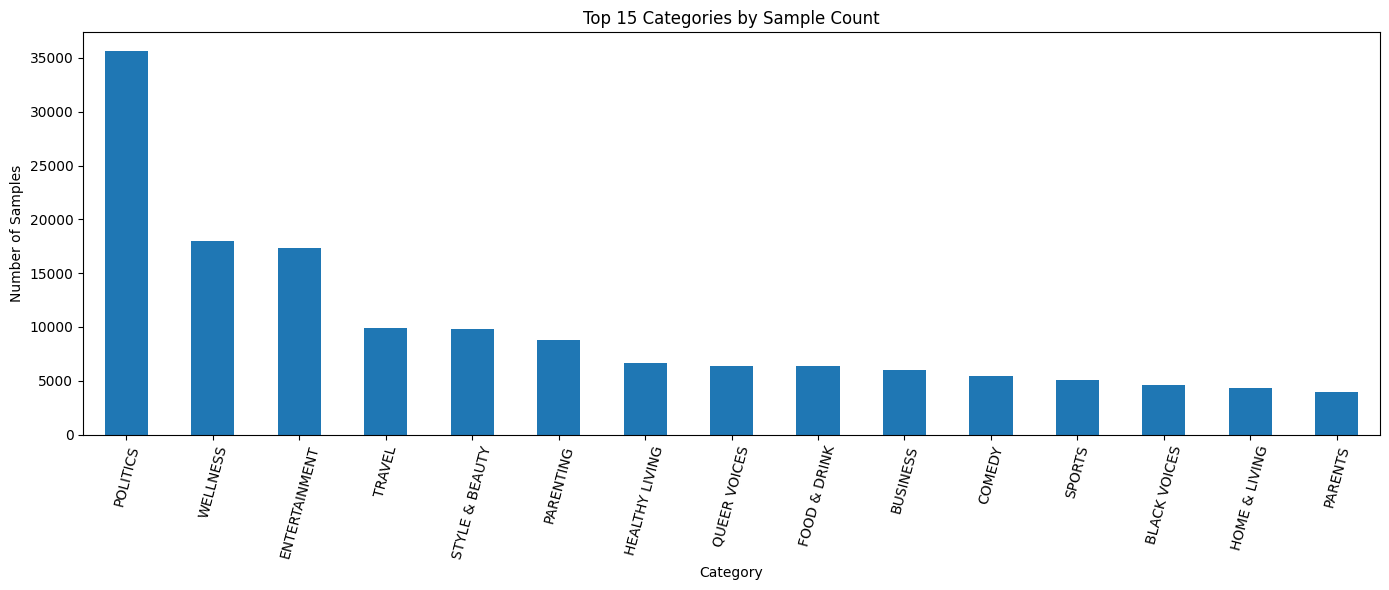

===== CLASS IMBALANCE =====
Largest class: POLITICS 35602
Smallest class: EDUCATION 1014
Imbalance ratio: 35.11


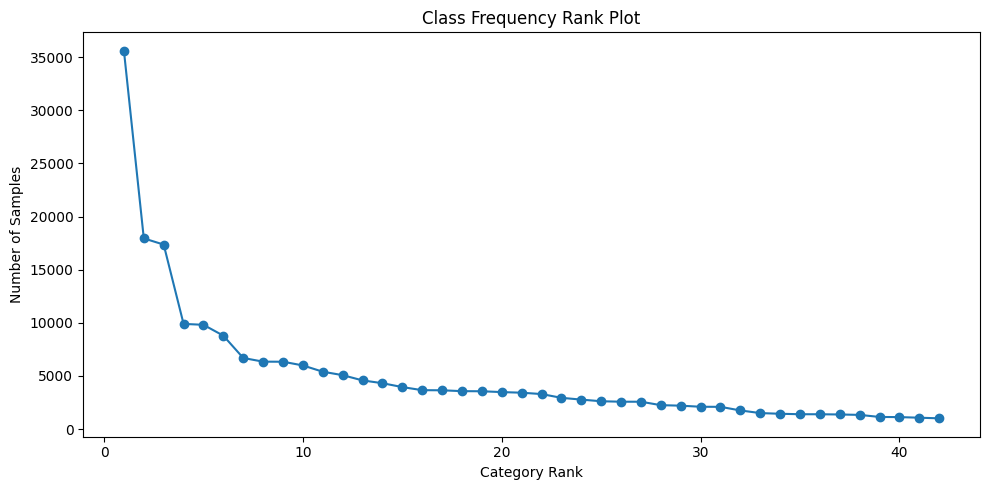

In [5]:
plt.figure(figsize=(14, 6))
category_counts.head(15).plot(kind="bar")
plt.title("Top 15 Categories by Sample Count")
plt.xlabel("Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig(RESULT_DIR / "eda_top15_category_distribution.png", dpi=150)
plt.show()

max_count = category_counts.max()
min_count = category_counts.min()
imbalance_ratio = max_count / min_count

print("===== CLASS IMBALANCE =====")
print("Largest class:", category_counts.idxmax(), max_count)
print("Smallest class:", category_counts.idxmin(), min_count)
print("Imbalance ratio:", round(imbalance_ratio, 2))

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(category_counts) + 1), category_counts.values, marker="o")
plt.title("Class Frequency Rank Plot")
plt.xlabel("Category Rank")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig(RESULT_DIR / "eda_class_rank_plot.png", dpi=150)
plt.show()

       headline_word_count  description_word_count  text_word_count  \
count        209527.000000           209527.000000    209527.000000   
mean              9.600744               19.669026        29.269770   
std               3.068507               14.152783        13.803927   
min               0.000000                0.000000         0.000000   
25%               8.000000               10.000000        20.000000   
50%              10.000000               19.000000        28.000000   
75%              12.000000               24.000000        35.000000   
max              44.000000              243.000000       245.000000   

       headline_char_count  description_char_count  text_char_count  
count        209527.000000           209527.000000    209527.000000  
mean             58.415355              114.208670       173.624025  
std              18.808506               80.840575        78.552970  
min               0.000000                0.000000         1.000000  
25%       

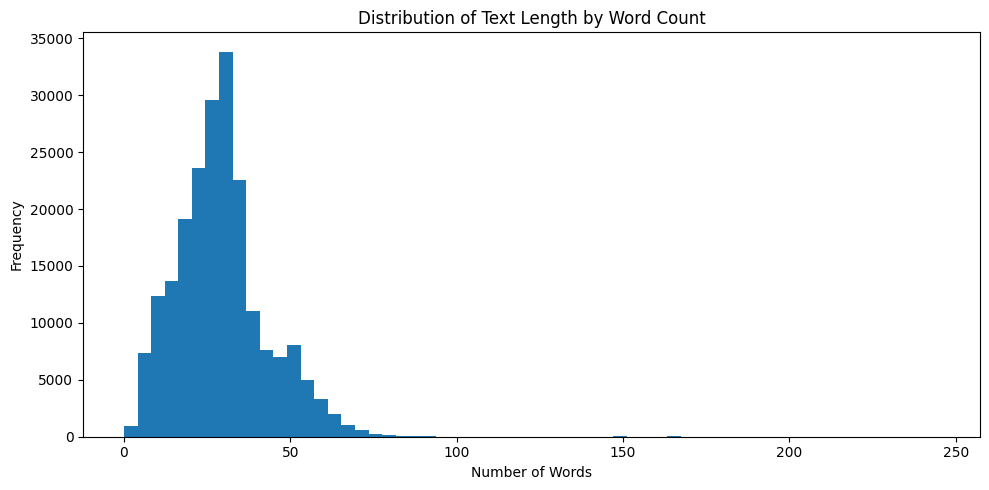

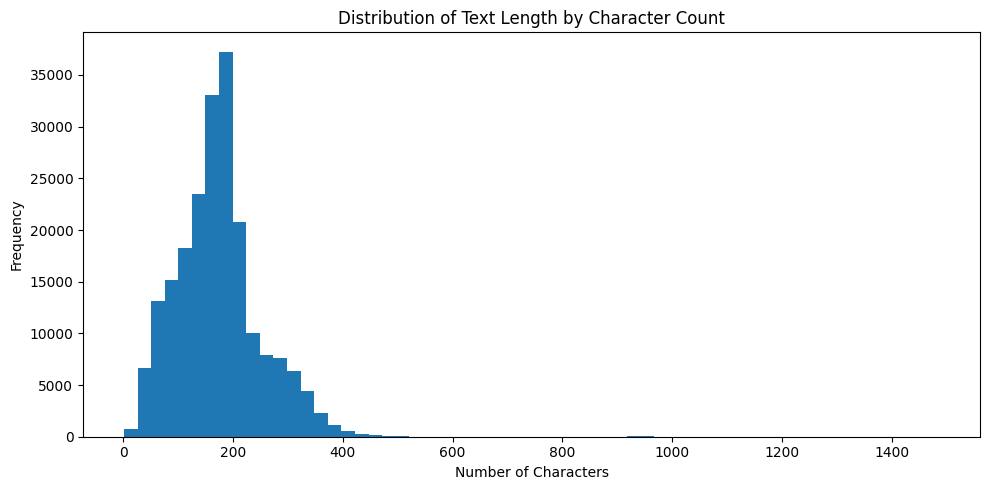

In [6]:
df["headline_word_count"] = df["headline"].apply(lambda x: len(str(x).split()))
df["description_word_count"] = df["short_description"].apply(lambda x: len(str(x).split()))
df["text_word_count"] = df["text"].apply(lambda x: len(str(x).split()))

df["headline_char_count"] = df["headline"].apply(len)
df["description_char_count"] = df["short_description"].apply(len)
df["text_char_count"] = df["text"].apply(len)

length_stats = df[
    [
        "headline_word_count",
        "description_word_count",
        "text_word_count",
        "headline_char_count",
        "description_char_count",
        "text_char_count"
    ]
].describe()

print(length_stats)
length_stats.to_csv(RESULT_DIR / "eda_length_statistics.csv")

plt.figure(figsize=(10, 5))
plt.hist(df["text_word_count"], bins=60)
plt.title("Distribution of Text Length by Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(RESULT_DIR / "eda_text_word_count_distribution.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df["text_char_count"], bins=60)
plt.title("Distribution of Text Length by Character Count")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(RESULT_DIR / "eda_text_char_count_distribution.png", dpi=150)
plt.show()

                count       mean  median        std  min  max
category                                                     
POLITICS        35602  26.267176    25.0  12.947379    0  245
WELLNESS        17945  39.036556    36.0  11.747990    3  171
ENTERTAINMENT   17362  23.200380    21.0  11.482405    1   98
TRAVEL           9900  34.757475    33.0  13.257635    1  175
STYLE & BEAUTY   9814  32.168229    32.0   8.167557    2  165
PARENTING        8791  38.456148    35.0  11.371665    5  150
HEALTHY LIVING   6694  28.302062    25.0  17.563082    1  176
QUEER VOICES     6347  29.784780    27.0  14.643220    0   85
FOOD & DRINK     6340  26.179495    25.0  10.631516    4  133
BUSINESS         5992  31.252003    30.0  15.368546    0  153
COMEDY           5400  22.673148    21.0  11.365423    1  128
SPORTS           5077  23.936971    22.0  11.560730    1   88
BLACK VOICES     4583  27.495309    27.0  11.379199    2  110
HOME & LIVING    4320  29.373843    30.0   9.459254    2  120
PARENTS 

/tmp/ipykernel_24/1911785254.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=top_10_categories_for_length, showfliers=False)


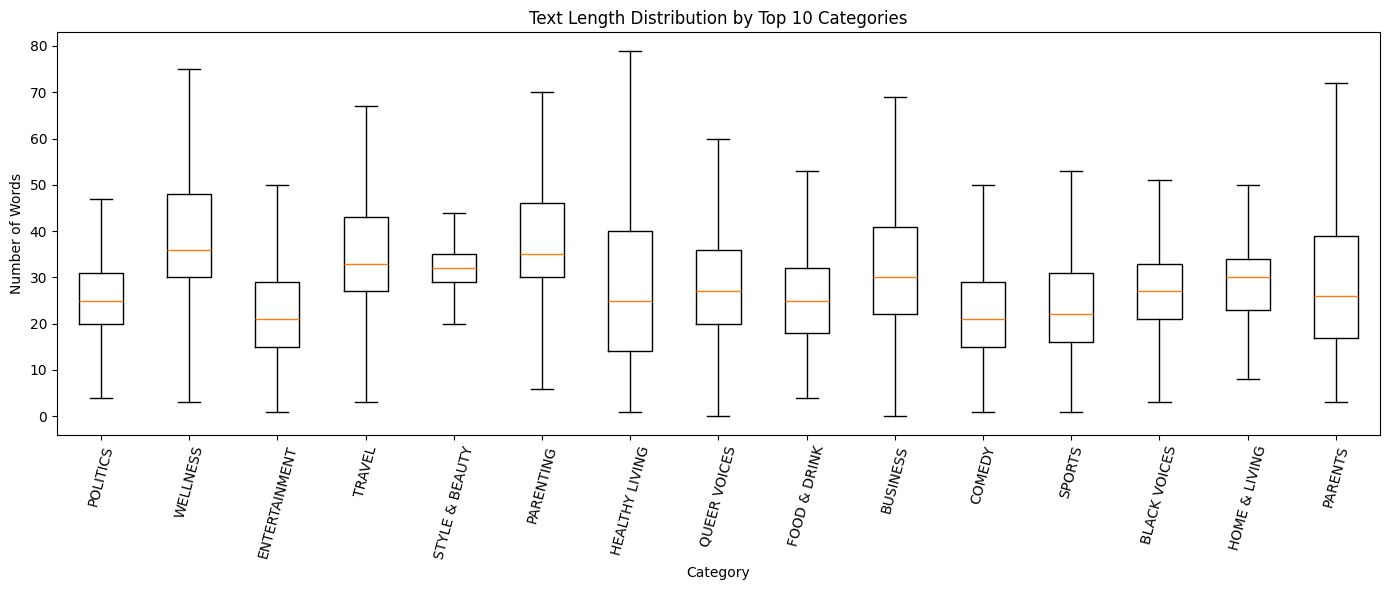

In [7]:
length_by_category = (
    df.groupby("category")["text_word_count"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("count", ascending=False)
)

print(length_by_category.head(20))
length_by_category.to_csv(RESULT_DIR / "eda_length_by_category.csv")

top_10_categories_for_length = category_counts.head(15).index
df_top10_for_length = df[df["category"].isin(top_10_categories_for_length)]

plt.figure(figsize=(14, 6))
data_to_plot = [
    df_top10_for_length[df_top10_for_length["category"] == cat]["text_word_count"]
    for cat in top_10_categories_for_length
]

plt.boxplot(data_to_plot, labels=top_10_categories_for_length, showfliers=False)
plt.title("Text Length Distribution by Top 10 Categories")
plt.xlabel("Category")
plt.ylabel("Number of Words")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig(RESULT_DIR / "eda_text_length_by_category_boxplot.png", dpi=150)
plt.show()

Vocabulary size: 107075
Total words after cleaning: 3408187
Top 30 words:
[('new', 19649), ('trump', 16506), ("it's", 13088), ('people', 12471), ('time', 12403), ('just', 12344), ('like', 11913), ('photos', 11424), ('day', 11199), ('year', 9628), ('life', 9481), ('make', 9218), ('said', 8057), ('world', 7902), ('know', 7679), ('video', 7514), ('best', 7496), ('says', 6997), ('want', 6975), ("don't", 6943), ('donald', 6884), ('love', 6842), ('week', 6826), ('way', 6815), ('years', 6757), ('women', 6499), ('need', 6339), ('president', 5981), ('good', 5802), ('health', 5727)]


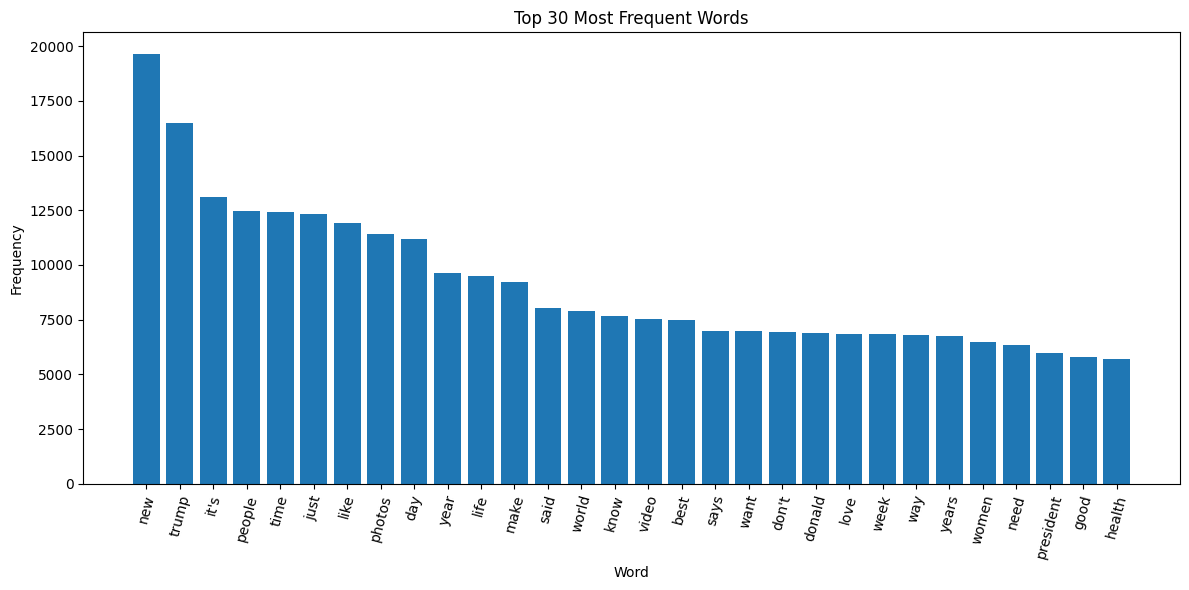

In [8]:
def eda_clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["eda_clean_text"] = df["text"].apply(eda_clean_text)

all_words = []

for text in df["eda_clean_text"]:
    words = text.split()
    words = [
        w for w in words
        if w not in ENGLISH_STOP_WORDS and len(w) > 2
    ]
    all_words.extend(words)

word_counts = Counter(all_words)

print("Vocabulary size:", len(word_counts))
print("Total words after cleaning:", len(all_words))
print("Top 30 words:")
print(word_counts.most_common(30))

top_words = word_counts.most_common(30)
top_words_df = pd.DataFrame(top_words, columns=["word", "count"])
top_words_df.to_csv(RESULT_DIR / "eda_top_words.csv", index=False)

words = [w for w, c in top_words]
counts = [c for w, c in top_words]

plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.title("Top 30 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig(RESULT_DIR / "eda_top30_words.png", dpi=150)
plt.show()

Top bigrams:
[('donald trump', np.int64(6666)), ('new york', np.int64(3291)), ('year old', np.int64(2902)), ('hillary clinton', np.int64(2029)), ('white house', np.int64(1790)), ('health care', np.int64(1279)), ('supreme court', np.int64(1222)), ('climate change', np.int64(1165)), ('check huffpost', np.int64(1040)), ('new year', np.int64(1038)), ('united states', np.int64(1029)), ('bernie sanders', np.int64(952)), ('years ago', np.int64(922)), ('twitter facebook', np.int64(910)), ('social media', np.int64(851)), ('sure check', np.int64(851)), ('want sure', np.int64(767)), ('york city', np.int64(742)), ('fashion week', np.int64(726)), ('don know', np.int64(709)), ('huffpost style', np.int64(709)), ('super bowl', np.int64(679)), ('facebook tumblr', np.int64(678)), ('high school', np.int64(671)), ('fox news', np.int64(670)), ('need know', np.int64(669)), ('tumblr pinterest', np.int64(642)), ('looks like', np.int64(635)), ('los angeles', np.int64(603)), ('north korea', np.int64(594))]

Top

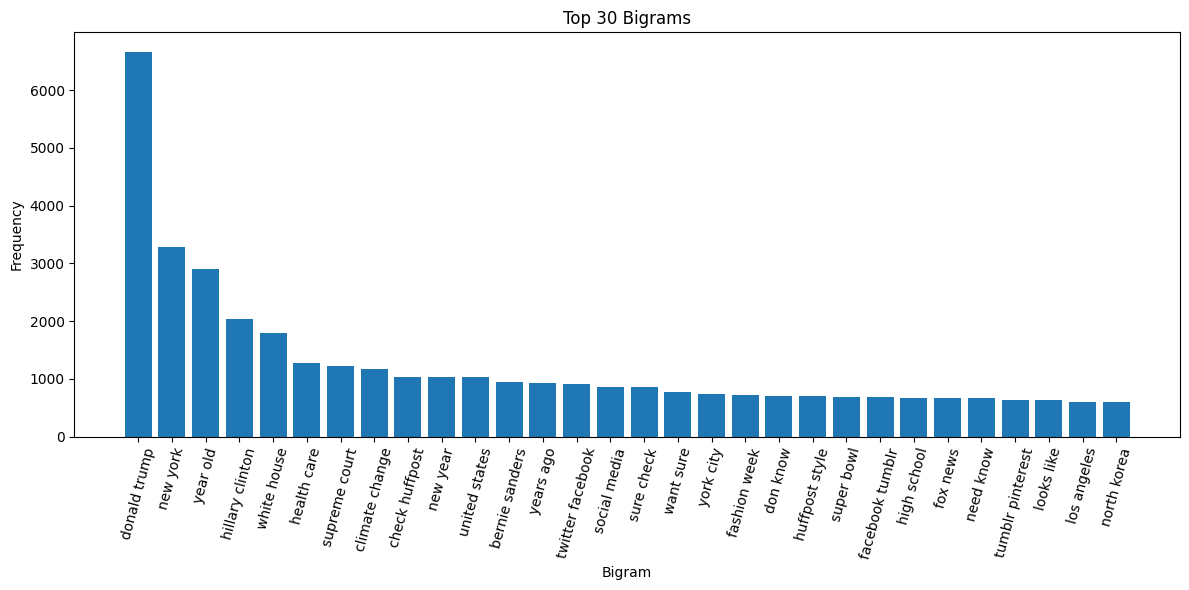

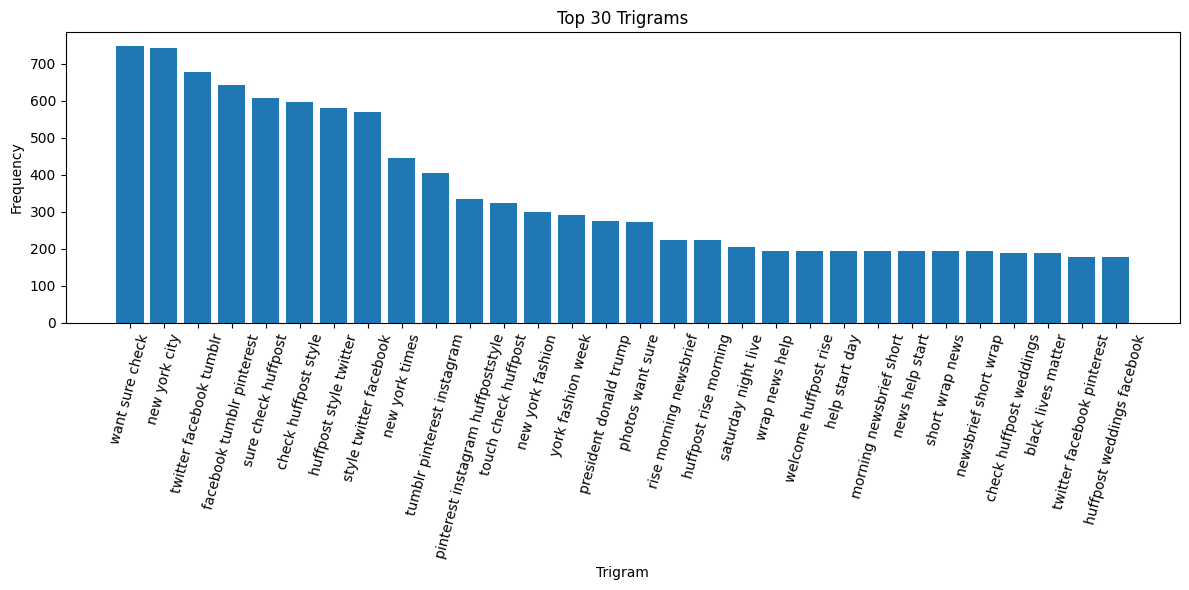

In [9]:
def get_top_ngrams(texts, ngram_range=(2, 2), top_n=30):
    vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=ngram_range,
        min_df=2
    )

    X_counts = vectorizer.fit_transform(texts)
    counts = np.asarray(X_counts.sum(axis=0)).ravel()
    vocab = np.array(vectorizer.get_feature_names_out())
    top_indices = counts.argsort()[::-1][:top_n]

    return list(zip(vocab[top_indices], counts[top_indices]))

top_bigrams = get_top_ngrams(df["eda_clean_text"], ngram_range=(2, 2), top_n=30)
top_trigrams = get_top_ngrams(df["eda_clean_text"], ngram_range=(3, 3), top_n=30)

pd.DataFrame(top_bigrams, columns=["bigram", "count"]).to_csv(
    RESULT_DIR / "eda_top_bigrams.csv",
    index=False
)

pd.DataFrame(top_trigrams, columns=["trigram", "count"]).to_csv(
    RESULT_DIR / "eda_top_trigrams.csv",
    index=False
)

print("Top bigrams:")
print(top_bigrams)

print("\nTop trigrams:")
print(top_trigrams)

bigrams, bigram_counts = zip(*top_bigrams)

plt.figure(figsize=(12, 6))
plt.bar(bigrams, bigram_counts)
plt.title("Top 30 Bigrams")
plt.xlabel("Bigram")
plt.ylabel("Frequency")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig(RESULT_DIR / "eda_top30_bigrams.png", dpi=150)
plt.show()

trigrams, trigram_counts = zip(*top_trigrams)

plt.figure(figsize=(12, 6))
plt.bar(trigrams, trigram_counts)
plt.title("Top 30 Trigrams")
plt.xlabel("Trigram")
plt.ylabel("Frequency")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig(RESULT_DIR / "eda_top30_trigrams.png", dpi=150)
plt.show()


Category: POLITICS
[('trump', np.int64(14592)), ('donald', np.int64(4660)), ('president', np.int64(3912)), ('new', np.int64(2826)), ('gop', np.int64(2807)), ('clinton', np.int64(2669)), ('said', np.int64(2633)), ('house', np.int64(2475)), ('obama', np.int64(2452)), ('says', np.int64(2388)), ('people', np.int64(2019)), ('state', np.int64(1925)), ('hillary', np.int64(1882)), ('white', np.int64(1838)), ('republican', np.int64(1644))]

Category: WELLNESS
[('life', np.int64(2763)), ('health', np.int64(2306)), ('people', np.int64(2059)), ('time', np.int64(1977)), ('new', np.int64(1804)), ('study', np.int64(1763)), ('day', np.int64(1445)), ('make', np.int64(1381)), ('like', np.int64(1372)), ('sleep', np.int64(1364)), ('cancer', np.int64(1322)), ('just', np.int64(1303)), ('don', np.int64(1146)), ('know', np.int64(1118)), ('love', np.int64(1113))]

Category: ENTERTAINMENT
[('new', np.int64(2064)), ('star', np.int64(1175)), ('trump', np.int64(1040)), ('just', np.int64(934)), ('film', np.int64(9

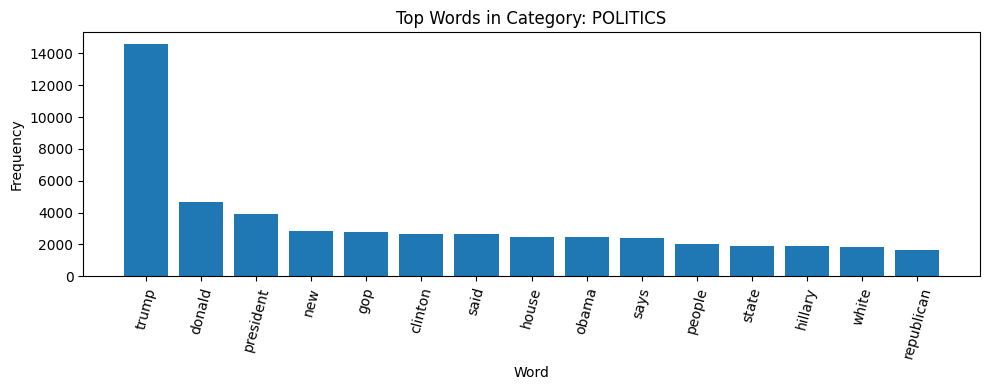

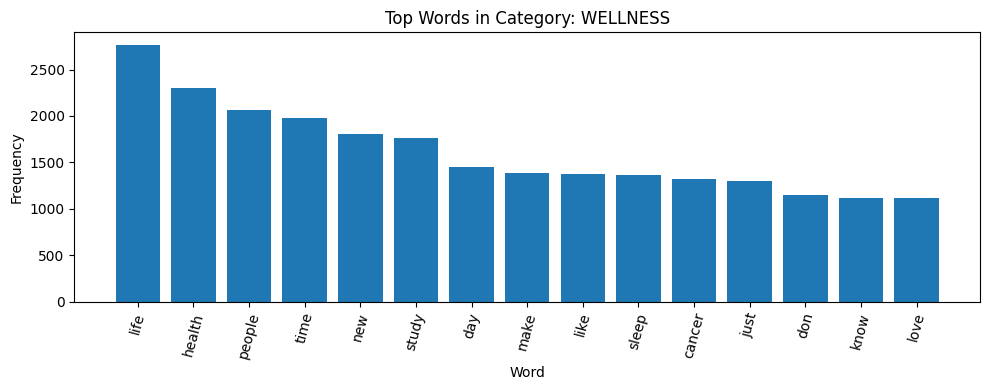

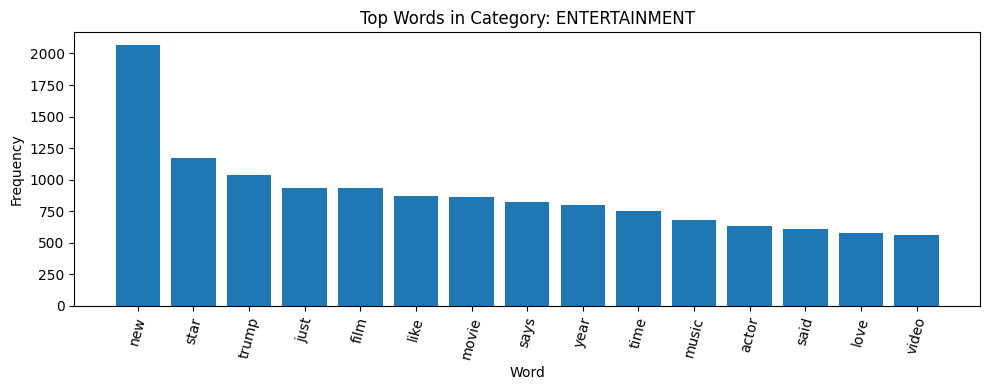

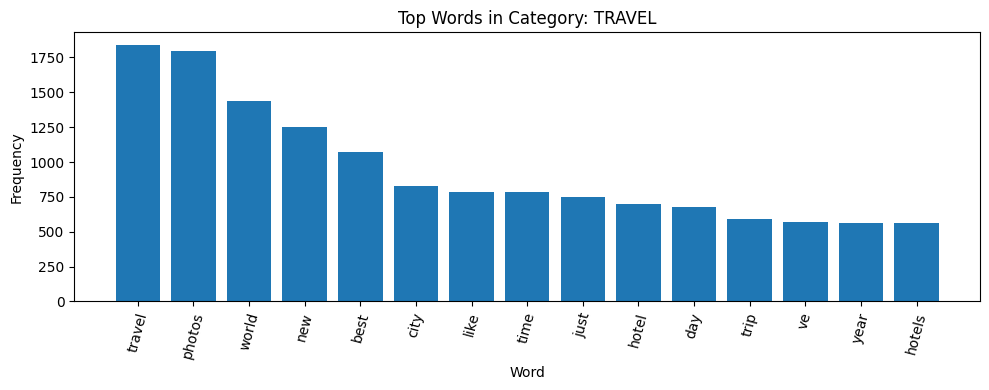

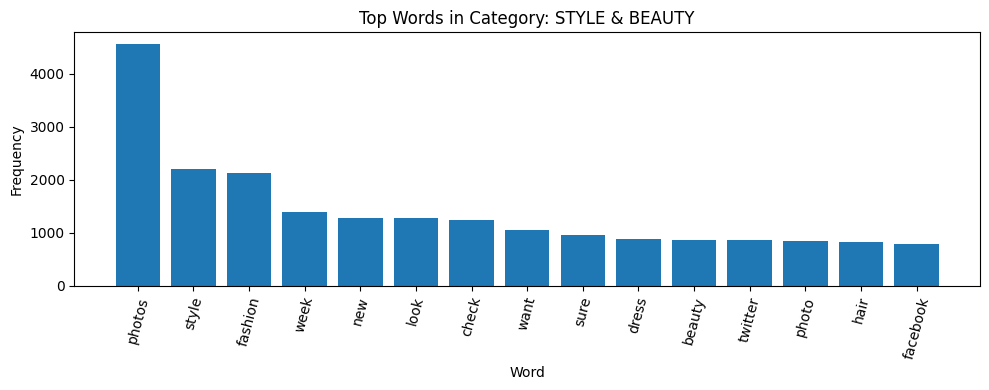

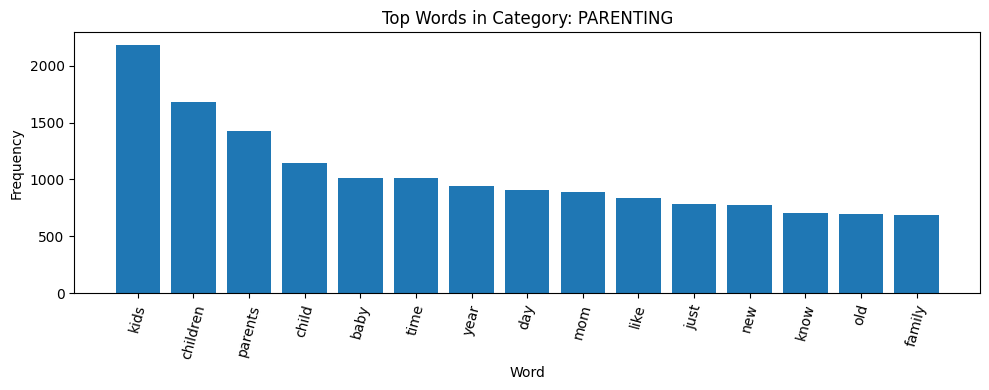

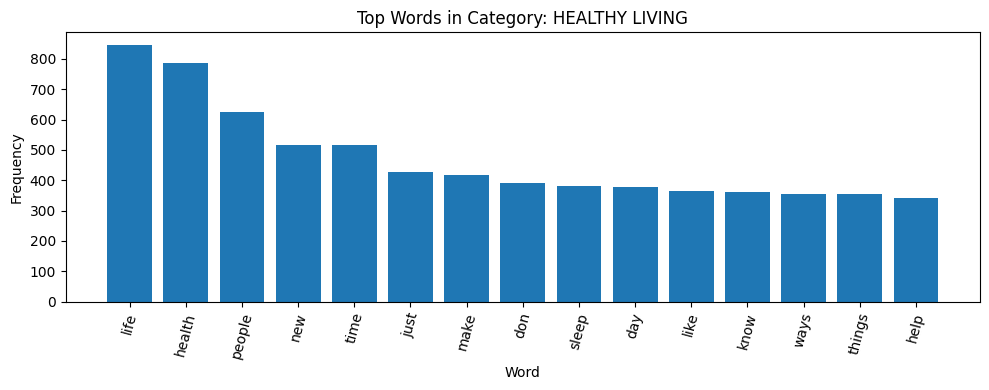

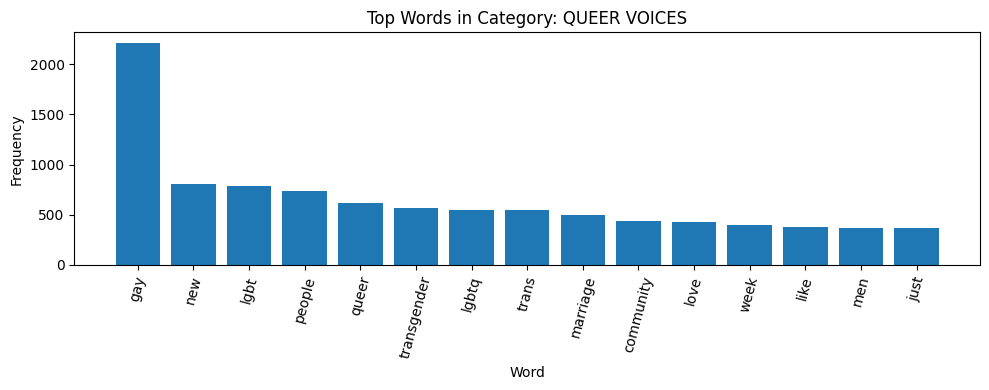

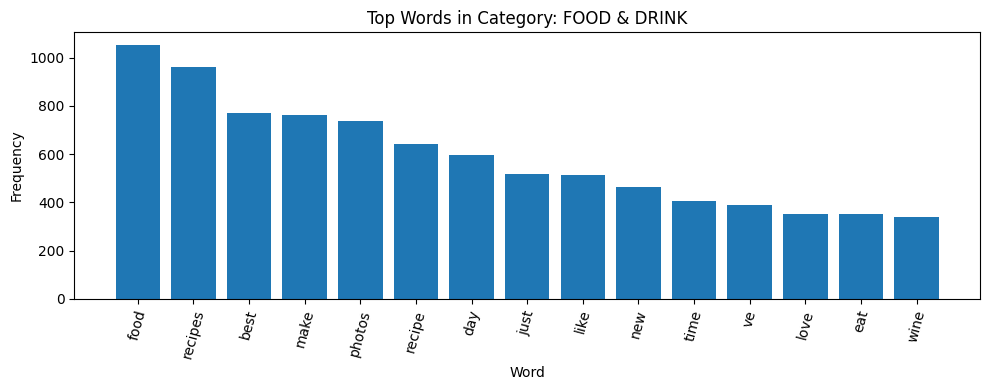

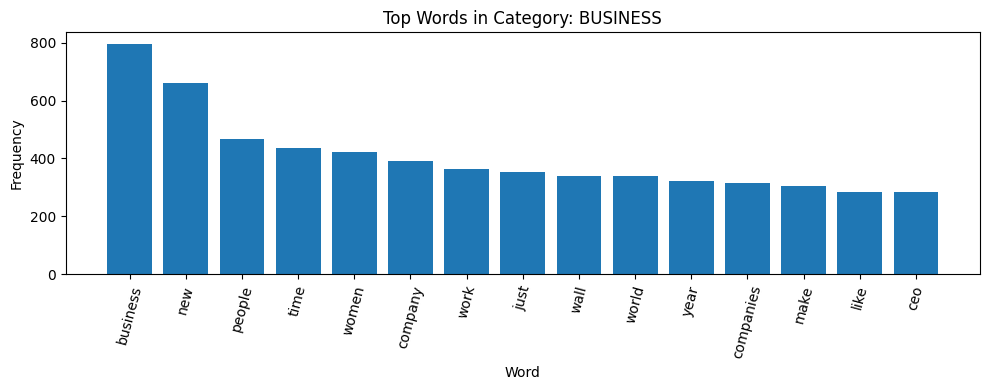

In [10]:
def top_words_by_category(dataframe, category, top_n=15):
    texts = dataframe[dataframe["category"] == category]["eda_clean_text"]

    vectorizer = CountVectorizer(
        stop_words="english",
        max_features=5000,
        min_df=2
    )

    X_counts = vectorizer.fit_transform(texts)
    counts = np.asarray(X_counts.sum(axis=0)).ravel()
    vocab = np.array(vectorizer.get_feature_names_out())
    top_indices = counts.argsort()[::-1][:top_n]

    return list(zip(vocab[top_indices], counts[top_indices]))

selected_categories = df["category"].value_counts().head(10).index.tolist()

category_keywords = {}

for cat in selected_categories:
    category_keywords[cat] = top_words_by_category(df, cat, top_n=15)

for cat, words_counts in category_keywords.items():
    print("\nCategory:", cat)
    print(words_counts)

# Lưu keywords ra file JSON
with open(RESULT_DIR / "eda_top_words_by_category.json", "w", encoding="utf-8") as f:
    json.dump(
        {cat: [(w, int(c)) for w, c in values] for cat, values in category_keywords.items()},
        f,
        ensure_ascii=False,
        indent=2
    )

# Vẽ top words cho 15 category đầu
for cat in selected_categories[:15]:
    words_counts = category_keywords[cat]
    words = [w for w, c in words_counts]
    counts = [c for w, c in words_counts]

    plt.figure(figsize=(10, 4))
    plt.bar(words, counts)
    plt.title(f"Top Words in Category: {cat}")
    plt.xlabel("Word")
    plt.ylabel("Frequency")
    plt.xticks(rotation=75)
    plt.tight_layout()

    safe_cat = re.sub(r"[^a-zA-Z0-9_]+", "_", cat.lower())
    plt.savefig(RESULT_DIR / f"eda_top_words_{safe_cat}.png", dpi=150)
    plt.show()

In [11]:
def top_tfidf_words_by_category(dataframe, category, top_n=15):
    category_df = dataframe[dataframe["category"] == category]

    vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2
    )

    X_tfidf = vectorizer.fit_transform(category_df["eda_clean_text"])
    mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()
    vocab = np.array(vectorizer.get_feature_names_out())
    top_indices = mean_tfidf.argsort()[::-1][:top_n]

    return list(zip(vocab[top_indices], mean_tfidf[top_indices]))

tfidf_keywords = {}

for cat in selected_categories:
    tfidf_keywords[cat] = top_tfidf_words_by_category(df, cat, top_n=15)

for cat, words_scores in tfidf_keywords.items():
    print("\nCategory:", cat)
    for word, score in words_scores:
        print(f"{word}: {score:.4f}")

with open(RESULT_DIR / "eda_tfidf_keywords_by_category.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            cat: [(w, float(s)) for w, s in values]
            for cat, values in tfidf_keywords.items()
        },
        f,
        ensure_ascii=False,
        indent=2
    )


Category: POLITICS
trump: 0.0325
donald: 0.0157
donald trump: 0.0154
president: 0.0130
clinton: 0.0111
gop: 0.0108
obama: 0.0106
new: 0.0102
house: 0.0095
said: 0.0093
says: 0.0091
hillary: 0.0085
people: 0.0080
state: 0.0077
white: 0.0076

Category: WELLNESS
life: 0.0157
health: 0.0133
people: 0.0125
time: 0.0121
study: 0.0114
new: 0.0110
sleep: 0.0101
day: 0.0096
cancer: 0.0093
make: 0.0092
like: 0.0092
just: 0.0087
love: 0.0083
know: 0.0082
don: 0.0080

Category: ENTERTAINMENT
new: 0.0142
star: 0.0094
trump: 0.0092
just: 0.0080
like: 0.0076
says: 0.0073
movie: 0.0073
film: 0.0070
year: 0.0069
time: 0.0067
music: 0.0059
season: 0.0057
actor: 0.0057
love: 0.0056
watch: 0.0055

Category: TRAVEL
travel: 0.0188
photos: 0.0172
world: 0.0155
new: 0.0134
best: 0.0122
city: 0.0099
like: 0.0097
time: 0.0096
just: 0.0092
hotel: 0.0092
day: 0.0086
trip: 0.0080
hotels: 0.0079
vacation: 0.0078
year: 0.0074

Category: STYLE & BEAUTY
photos: 0.0279
style: 0.0199
fashion: 0.0192
week: 0.0143
check:

Selected top categories:
['POLITICS', 'WELLNESS', 'ENTERTAINMENT', 'TRAVEL', 'STYLE & BEAUTY', 'PARENTING', 'HEALTHY LIVING', 'QUEER VOICES', 'FOOD & DRINK', 'BUSINESS', 'COMEDY', 'SPORTS', 'BLACK VOICES', 'HOME & LIVING', 'PARENTS']

Shape after selecting top categories: (148122, 11)
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
Name: count, dtype: int64


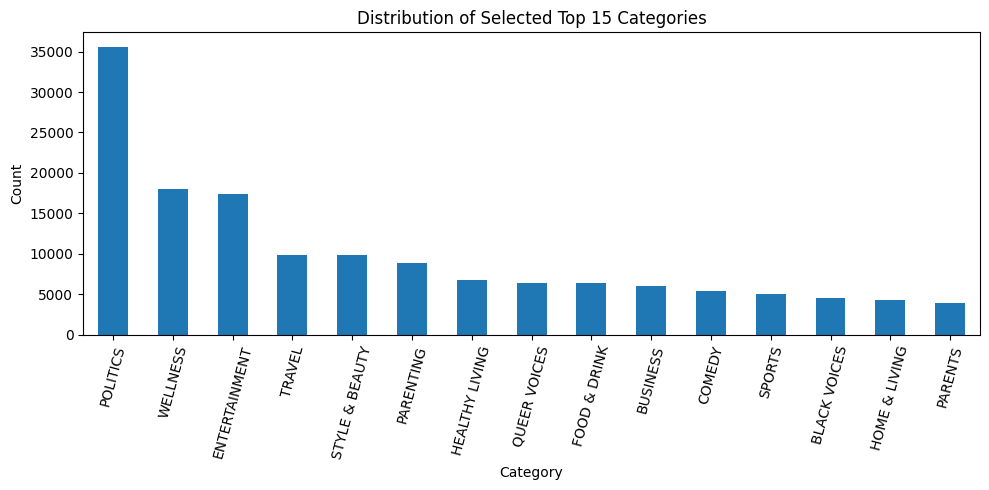

In [12]:
top_categories = df["category"].value_counts().head(TOP_K).index.tolist()
df_top = df[df["category"].isin(top_categories)].copy()

if MAX_SAMPLES_PER_CLASS is not None:
    df_top = (
        df_top.groupby("category", group_keys=False)
        .apply(lambda x: x.sample(
            n=min(len(x), MAX_SAMPLES_PER_CLASS),
            random_state=SEED
        ))
        .reset_index(drop=True)
    )

print("Selected top categories:")
print(top_categories)

print("\nShape after selecting top categories:", df_top.shape)
print(df_top["category"].value_counts())

plt.figure(figsize=(10, 5))
df_top["category"].value_counts().plot(kind="bar")
plt.title(f"Distribution of Selected Top {TOP_K} Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig(RESULT_DIR / f"eda_top{TOP_K}_category_distribution.png", dpi=150)
plt.show()

In [13]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df_top = df_top.drop_duplicates(subset=["text"]).reset_index(drop=True)
df_top["clean_text"] = df_top["text"].apply(clean_text)

print(df_top[["category", "text", "clean_text"]].head())

        category                                               text  \
0         COMEDY  23 Of The Funniest Tweets About Cats And Dogs ...   
1      PARENTING  The Funniest Tweets From Parents This Week (Se...   
2         SPORTS  Maury Wills, Base-Stealing Shortstop For Dodge...   
3  ENTERTAINMENT  Golden Globes Returning To NBC In January Afte...   
4       POLITICS  Biden Says U.S. Forces Would Defend Taiwan If ...   

                                          clean_text  
0  23 of the funniest tweets about cats and dogs ...  
1  the funniest tweets from parents this week sep...  
2  maury wills base stealing shortstop for dodger...  
3  golden globes returning to nbc in january afte...  
4  biden says u s forces would defend taiwan if c...  


In [14]:
label_encoder = LabelEncoder()
df_top["label"] = label_encoder.fit_transform(df_top["category"])

num_classes = len(label_encoder.classes_)

id2label = {int(i): label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: int(i) for i, label in id2label.items()}

print("Number of classes:", num_classes)
print("id2label:")
print(id2label)

with open(RESULT_DIR / "label_mapping.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "id2label": id2label,
            "label2id": label2id
        },
        f,
        ensure_ascii=False,
        indent=2
    )

with open(MODEL_DIR / "label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

Number of classes: 15
id2label:
{0: 'BLACK VOICES', 1: 'BUSINESS', 2: 'COMEDY', 3: 'ENTERTAINMENT', 4: 'FOOD & DRINK', 5: 'HEALTHY LIVING', 6: 'HOME & LIVING', 7: 'PARENTING', 8: 'PARENTS', 9: 'POLITICS', 10: 'QUEER VOICES', 11: 'SPORTS', 12: 'STYLE & BEAUTY', 13: 'TRAVEL', 14: 'WELLNESS'}


In [15]:
X = df_top["clean_text"].values
y = df_top["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 103467
Validation: 22171
Test: 22172


In [16]:
tokenizer = Tokenizer(
    #num_words=MAX_WORDS,
    oov_token="<OOV>",
    lower=True
)

# Chỉ fit tokenizer trên train set để tránh data leakage
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)
max_len_train = max(len(seq) for seq in X_train_seq)
max_len_val = max(len(seq) for seq in X_val_seq)
max_len_test = max(len(seq) for seq in X_test_seq)

print("Max sequence length - Train:", max_len_train)
print("Max sequence length - Val:", max_len_val)
print("Max sequence length - Test:", max_len_test)

print("Overall max sequence length:", max(max_len_train, max_len_val, max_len_test))

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

vocab_size =  len(tokenizer.word_index) + 1

print("Vocabulary size:", vocab_size)
print("X_train_pad shape:", X_train_pad.shape)
print("X_val_pad shape:", X_val_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

# Lưu tokenizer
tokenizer_json = tokenizer.to_json()
with open(MODEL_DIR / "tokenizer.json", "w", encoding="utf-8") as f:
    f.write(tokenizer_json)

# Lưu features dạng sequence
np.save(FEATURE_DIR / "X_train_sequence.npy", X_train_pad)
np.save(FEATURE_DIR / "X_val_sequence.npy", X_val_pad)
np.save(FEATURE_DIR / "X_test_sequence.npy", X_test_pad)

np.save(FEATURE_DIR / "y_train.npy", y_train)
np.save(FEATURE_DIR / "y_val.npy", y_val)
np.save(FEATURE_DIR / "y_test.npy", y_test)

Max sequence length - Train: 248
Max sequence length - Val: 165
Max sequence length - Test: 198
Overall max sequence length: 248
Vocabulary size: 77581
X_train_pad shape: (103467, 30)
X_val_pad shape: (22171, 30)
X_test_pad shape: (22172, 30)


In [17]:
# =========================
# In thử một vài kết quả tokenization + padding
# =========================

# Tạo từ điển ngược: id -> word
index_word = {idx: word for word, idx in tokenizer.word_index.items()}

def decode_sequence(seq):
    words = []
    for idx in seq:
        if idx == 0:
            words.append("<PAD>")
        else:
            words.append(index_word.get(idx, "<OOV>"))
    return words

# In 3 mẫu đầu tiên trong train set
for i in range(3):
    print("=" * 100)
    print(f"MẪU THỨ {i+1}")
    
    print("\nText gốc:")
    print(X_train[i])
    
    print("\nSequence trước padding:")
    print(X_train_seq[i])
    
    print("\nĐộ dài sequence trước padding:")
    print(len(X_train_seq[i]))
    
    print("\nSequence sau padding:")
    print(X_train_pad[i])
    
    print("\nĐộ dài sequence sau padding:")
    print(len(X_train_pad[i]))
    
    print("\nDecode lại sequence sau padding:")
    print(decode_sequence(X_train_pad[i]))
    
    print("\nLabel dạng số:")
    print(y_train[i])
    
    print("\nLabel dạng chữ:")
    print(id2label[int(y_train[i])])

MẪU THỨ 1

Text gốc:
valentine's day ideas make these adorable diy robot cards who said robots can't be sweet

Sequence trước padding:
[1179, 63, 588, 72, 83, 1038, 1269, 6574, 2562, 49, 85, 9994, 215, 17, 847]

Độ dài sequence trước padding:
15

Sequence sau padding:
[1179   63  588   72   83 1038 1269 6574 2562   49   85 9994  215   17
  847    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]

Độ dài sequence sau padding:
30

Decode lại sequence sau padding:
["valentine's", 'day', 'ideas', 'make', 'these', 'adorable', 'diy', 'robot', 'cards', 'who', 'said', 'robots', "can't", 'be', 'sweet', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']

Label dạng số:
6

Label dạng chữ:
HOME & LIVING
MẪU THỨ 2

Text gốc:
fox's lou dobbs lavishes praise on donald trump as u s coronavirus deaths top 100 000 the fox business host faced backlash over his latest outlandish claim about the pres

In [18]:
classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_array)
}

print("Class weights:")
print(class_weights)

with open(RESULT_DIR / "class_weights.json", "w") as f:
    json.dump(class_weights, f, indent=2)

Class weights:
{0: 2.1521996879875194, 1: 1.6454675572519084, 2: 1.8282003710575139, 3: 0.5676734425150194, 4: 1.5546089700247916, 5: 1.4732592909013242, 6: 2.2977348434377083, 7: 1.124519074013694, 8: 2.5285190615835775, 9: 0.27690887193898034, 10: 1.5535585585585585, 11: 1.940855374226224, 12: 1.0181254612546125, 13: 0.995784610942688, 14: 0.5493191048817393}


In [19]:
@register_keras_serializable()
class MaskedAttentionLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        # input_shape[0] là shape của output BiLSTM: (batch, time_steps, hidden_size)
        hidden_size = input_shape[0][-1]

        self.W = self.add_weight(
            name="attention_weight",
            shape=(hidden_size, 1),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            name="attention_bias",
            shape=(1,),
            initializer="zeros",
            trainable=True
        )

        super().build(input_shape)

    def call(self, inputs):
        sequence_outputs, token_ids = inputs
        # sequence_outputs: output BiLSTM, shape (batch, time_steps, hidden_size)
        # token_ids: input ban đầu, shape (batch, time_steps)

        score = tf.matmul(sequence_outputs, self.W) + self.b
        score = tf.squeeze(tf.tanh(score), axis=-1)

        # Tự tạo mask: token khác 0 là token thật, token 0 là padding
        mask = tf.cast(tf.not_equal(token_ids, 0), dtype=tf.float32)

        # Padding nhận điểm rất nhỏ để softmax gần như không chú ý vào padding
        score = score + (1.0 - mask) * -1e9

        attention_weights = tf.nn.softmax(score, axis=1)
        attention_weights = tf.expand_dims(attention_weights, axis=-1)

        context_vector = tf.reduce_sum(sequence_outputs * attention_weights, axis=1)

        return context_vector

In [20]:
from tensorflow.keras import regularizers
def build_bilstm_attention_model(
    vocab_size,
    max_len,
    embed_dim,
    lstm_units,
    num_classes,
    learning_rate
):
    inputs = layers.Input(shape=(max_len,), name="input_ids")

    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        mask_zero= False,
        name="embedding"
    )(inputs)

    x = layers.SpatialDropout1D(0.3, name="spatial_dropout")(x)

    x = layers.Bidirectional(
        layers.LSTM(
            lstm_units,
            return_sequences=True,
            dropout=0.3,
            use_cudnn=False
        ),
        name="bilstm"
    )(x)

    x = MaskedAttentionLayer(name="masked_attention")([x, inputs])

    x = layers.Dropout(0.3, name="dropout_after_attention")(x)

    document_embedding = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
        name="document_embedding"
    )(x)

    x = layers.Dropout(0.3, name="dropout_before_output")(document_embedding)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        kernel_regularizer=regularizers.l2(1e-4),
        name="category_output"
    )(x)

    model = Model(inputs=inputs, outputs=outputs, name="BiLSTM_Attention_Text_Classifier")

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

model = build_bilstm_attention_model(
    vocab_size=vocab_size,
    max_len=MAX_LEN,
    embed_dim=EMBED_DIM,
    lstm_units=LSTM_UNITS,
    num_classes=num_classes,
    learning_rate=LEARNING_RATE
)

model.summary()

I0000 00:00:1778250350.186507      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778250350.192561      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "BiLSTM_Attention_Text_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 30, 128)   │  9,930,368 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 30, 128)   │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 30, 256)   │    263,168 │ spatial_dropout[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_attention    │ (None, 256)       │        257 │ bilstm[0][0],     │
│ (MaskedAttentionLa… │                   │            │ input_ids[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_after_atte… │ (None, 256)       │          0 │ masked_attention… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ document_embedding  │ (None, 128)       │     32,896 │ dropout_after_at… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_before_out… │ (None, 128)       │          0 │ document_embeddi… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ category_output     │ (None, 15)        │      1,935 │ dropout_before_o… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,228,624 (39.02 MB)

 Trainable params: 10,228,624 (39.02 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
best_model_path = MODEL_DIR / "bilstm_attention_best.keras"

callbacks = [
    ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    ),
    CSVLogger(
        filename=RESULT_DIR / "training_log.csv",
        append=False
    )
]

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20


I0000 00:00:1778250356.194137      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


807/809 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4003 - loss: 1.9456
Epoch 1: val_loss improved from inf to 0.97418, saving model to /kaggle/working/models/bilstm_attention_best.keras
809/809 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.4009 - loss: 1.9440 - val_accuracy: 0.7171 - val_loss: 0.9742 - learning_rate: 0.0020
Epoch 2/20
809/809 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7255 - loss: 0.9533
Epoch 2: val_loss improved from 0.97418 to 0.92999, saving model to /kaggle/working/models/bilstm_attention_best.keras
809/809 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.7256 - loss: 0.9532 - val_accuracy: 0.7278 - val_loss: 0.9300 - learning_rate: 0.0020
Epoch 3/20
807/809 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7926 - loss: 0.6859
Epoch 3: val_loss did not improve from 0.92999

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0010000000474974513.
809/809 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7926 - loss: 0.6858 - val_accuracy: 0.7243 - val_

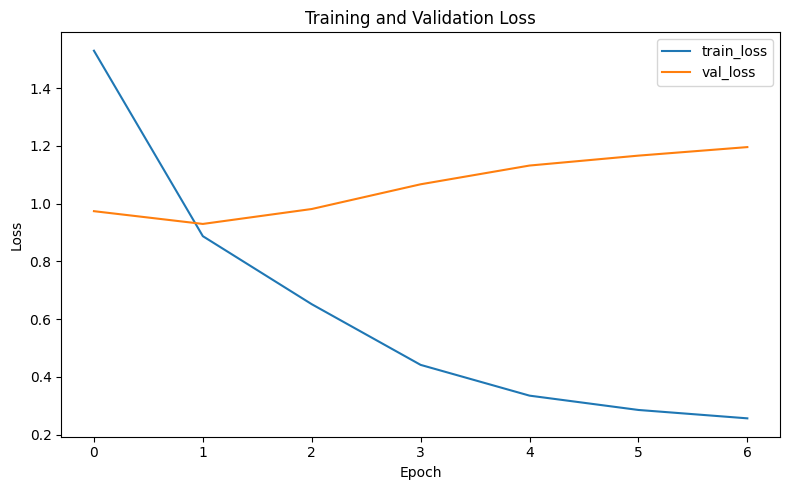

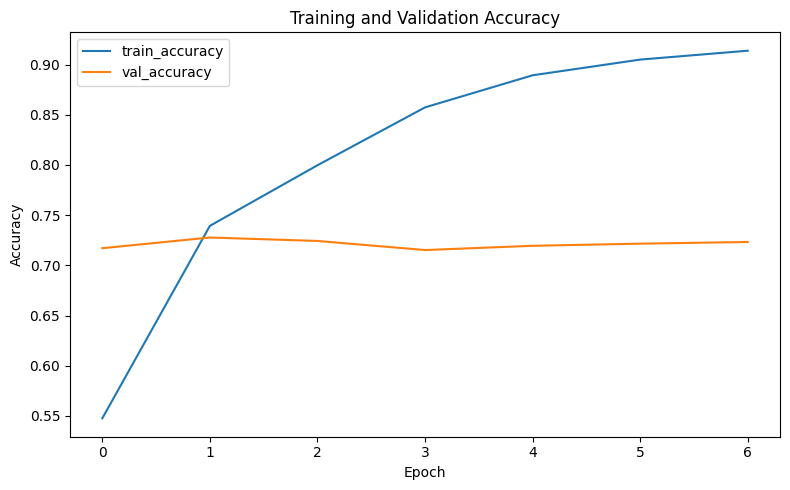

In [22]:
history_df = pd.DataFrame(history.history)
history_df.to_csv(RESULT_DIR / "training_history.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "loss_curve.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "accuracy_curve.png", dpi=150)
plt.show()

In [23]:
best_model = tf.keras.models.load_model(
    best_model_path,
    custom_objects={
        "MaskedAttentionLayer": MaskedAttentionLayer,
        "Custom>MaskedAttentionLayer": MaskedAttentionLayer
    }
)

y_test_prob = best_model.predict(X_test_pad, batch_size=BATCH_SIZE)
y_test_pred = np.argmax(y_test_prob, axis=1)

accuracy = accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average="macro")
weighted_f1 = f1_score(y_test, y_test_pred, average="weighted")
macro_precision = precision_score(y_test, y_test_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_test, y_test_pred, average="macro", zero_division=0)

metrics = {
    "accuracy": float(accuracy),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall)
}

print("Test metrics:")
print(json.dumps(metrics, indent=2))

with open(RESULT_DIR / "test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

target_names = label_encoder.classes_

report = classification_report(
    y_test,
    y_test_pred,
    target_names=target_names,
    digits=4,
    zero_division=0
)

print(report)

with open(RESULT_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Test metrics:
{
  "accuracy": 0.7363792170304889,
  "macro_f1": 0.6881056431206921,
  "weighted_f1": 0.7398169017335547,
  "macro_precision": 0.6728342451768964,
  "macro_recall": 0.7129737068286154
}
                precision    recall  f1-score   support

  BLACK VOICES     0.4815    0.6647    0.5585       686
      BUSINESS     0.5368    0.6737    0.5975       898
        COMEDY     0.4492    0.6238    0.5223       808
 ENTERTAINMENT     0.7965    0.6912    0.7401      2604
  FOOD & DRINK     0.7828    0.8149    0.7986       951
HEALTHY LIVING     0.5074    0.4074    0.4519      1004
 HOME & LIVING     0.6891    0.8274    0.7519       643
     PARENTING     0.6686    0.7057    0.6866      1315
       PARENTS     0.4877    0.4401    0.4626       584
      POLITICS     0.9336    0.7844    0.8525      5338
  QUEER VOICES     0.7470    0.7878    0.7669       952
        SPORTS     0.6713    0.8265    0.7409       761
STYLE & BEAUTY     0.8181    

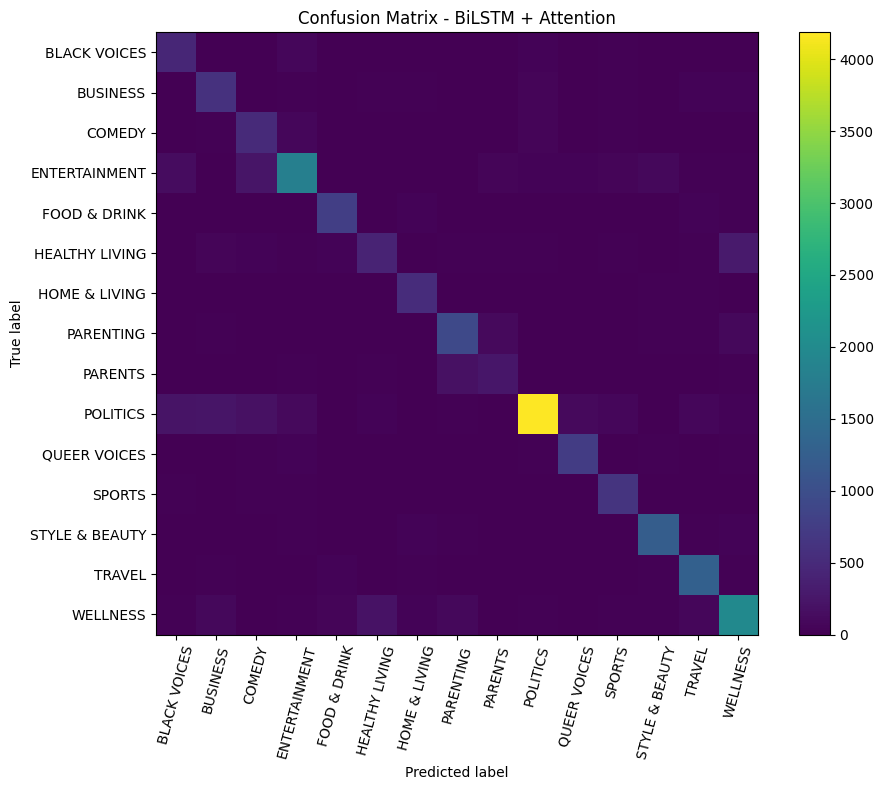

In [24]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix - BiLSTM + Attention")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(ticks=np.arange(num_classes), labels=target_names, rotation=75)
plt.yticks(ticks=np.arange(num_classes), labels=target_names)
plt.colorbar()
plt.tight_layout()
plt.savefig(RESULT_DIR / "confusion_matrix.png", dpi=150)
plt.show()